# Phase 4 — 2D 객체 검출 기준선 (실무 방식 재구성)

정답지: `notebooks/04_yolo_detection.ipynb`, `src/perceptrack3d/detection/detector.py`, `src/perceptrack3d/visualization/boxes2d.py`, `outputs/phase4/detections.json`.
이 노트북은 같은 결과를 **검색해서 가져다 붙이는 방식**으로 다시 만든다. 조각 셀에서는 정답지 모듈을 쓰지 않고, 검증(C) 셀에서만 import 한다.

목표 함수: `detect(img, frame_id) -> list[dict(frame_id, class_name, class_id, confidence, xyxy)]` 와 JSON 저장/로드.
입력: `(375, 1242, 3) uint8 BGR` (cv2.imread 그대로). 출력 `xyxy` 는 image_02 픽셀 (x1, y1, x2, y2), 원점 좌상단.
모델: 사전학습 yolov8n (COCO 80 클래스), 학습하지 않음, CPU.

## 이 노트북에서 가져오는 것

| 조각 | 출처 | 라이선스 | 왜 |
|---|---|---|---|
| 1. `model(cv2.imread(...))` 입력 형식 | ultralytics 문서 predict "Inference Sources" (OpenCV / NumPy 행) | AGPL-3.0 (ultralytics 저장소 docs) | ndarray 입력이 **HWC, BGR, uint8** 임을 공식 문서로 확정 |
| 2. `results[0].boxes.xyxy / conf / cls` | ultralytics 문서 predict "Working with Results", "Boxes" | 위와 같음 | 결과 객체에서 숫자를 꺼내는 공식 경로 |
| 3. `results[0].plot()` vs `cv2.rectangle` | ultralytics 문서 "Plotting Results", OpenCV drawing functions 문서 | AGPL-3.0 / Apache-2.0 | 결과를 그리는 두 방법. 우리 형식(dict)에서는 cv2 직접 그리기 |
| 4. `model.names`, `classes=` 필터, COCO↔KITTI | ultralytics `Results.names`, `cfg/default.yaml` `classes:`; KITTI object devkit `readme.txt` | AGPL-3.0 / KITTI | 80 클래스 중 도로 객체 6개만 남기고, KITTI 라벨과 1:1 이 아님을 표로 |
| 5. `time.perf_counter`, `results[0].speed` | Python 문서 `time.perf_counter`; ultralytics `Results.speed` | PSF / AGPL-3.0 | warm-up 후 프레임당 시간. ultralytics 내부 측정과 비교 |
| 6. `agnostic_nms` 실험 (실패 사례) | ultralytics `cfg/default.yaml` `agnostic_nms:` | AGPL-3.0 | 같은 물체에 truck+bus 이중 박스가 왜 남는지, 켜면 무엇이 달라지는지 |

In [1]:
# 공통 준비: 경로와 검출 설정은 config 에서만 가져온다.
%matplotlib inline
import json
import time
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

from perceptrack3d.config import load_config
cfg = load_config()
DET = cfg["detection"]                                            # model, conf_threshold, iou_threshold, device, keep_classes, imgsz
IMAGE_DIR = Path(cfg["dataset"]["image_dir"])
MODEL_PATH = Path(cfg["outputs"]["dir"]) / "models" / DET["model"]   # outputs/models/yolov8n.pt (정답지 resolve_model_path 와 같은 위치)
OUT_DIR = Path(cfg["outputs"]["dir"]) / "notebooks_2nd"
OUT_DIR.mkdir(parents=True, exist_ok=True)
ANSWER_JSON = Path(cfg["outputs"]["dir"]) / "phase4" / "detections.json"

FRAME = 36
IMG_PATH = IMAGE_DIR / f"{FRAME:010d}.png"
img = cv2.imread(str(IMG_PATH))
print("image:", img.shape, img.dtype, "| BGR (OpenCV)")
print("model:", MODEL_PATH, "| exists:", MODEL_PATH.is_file())
print("detection cfg:", {k: DET[k] for k in ("conf_threshold", "iou_threshold", "imgsz", "device", "keep_classes")})

image: (375, 1242, 3) uint8 | BGR (OpenCV)
model: /home/ingon/study/PercepTrack3D/outputs/models/yolov8n.pt | exists: True
detection cfg: {'conf_threshold': 0.25, 'iou_threshold': 0.45, 'imgsz': 640, 'device': 'cpu', 'keep_classes': ['car', 'truck', 'bus', 'person', 'bicycle', 'motorcycle']}


### 조각 1. OpenCV 이미지를 그대로 넣기 — ultralytics predict "Inference Sources"

- **검색어**: `ultralytics yolo predict opencv image numpy array`
- **출처**: Ultralytics 문서 "Model Prediction with Ultralytics YOLO" — https://docs.ultralytics.com/modes/predict/#inference-sources — AGPL-3.0 (저장소 `docs/en/modes/predict.md`) — 2026-09-08 — `notebooks_2nd/sources/ultralytics/predict.md`
- **왜 이걸 가져오나**: `cv2.imread` 결과(BGR)를 RGB 로 바꿔야 하는지가 가장 흔한 질문이다. 표에 **"HWC format with BGR channels uint8 (0-255)"** 라고 명시되어 있으므로 색 변환 없이 넣는다.
- **읽을 때 볼 곳**: "Inference Sources" 표의 OpenCV / NumPy 행, 그 아래 "OpenCV" 탭 예제.

**원문 — 표 발췌**
```text
| Source                                                | Example                                    | Type            | Notes                                                                                        |
| ----------------------------------------------------- | ------------------------------------------ | --------------- | -------------------------------------------------------------------------------------------- |
| [OpenCV](https://www.ultralytics.com/glossary/opencv) | `cv2.imread('image.jpg')`                  | `np.ndarray`    | HWC format with BGR channels `uint8 (0-255)`.                                                |
| NumPy                                                 | `np.zeros((640,1280,3))`                   | `np.ndarray`    | HWC format with BGR channels `uint8 (0-255)`.                                                |
```

**원문 — "OpenCV" 탭 예제**
```python
import cv2

from ultralytics import YOLO

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Read an image using OpenCV
source = cv2.imread("path/to/image.jpg")

# Run inference on the source
results = model(source)  # list of Results objects
```

문서 예제는 자리표시자(`yolo26n.pt`, `path/to/image.jpg`)가 있어 그대로는 못 돌린다. 그 줄만 바꾸고 `# CHANGED` 로 표시한다. 문서는 최신 모델(yolo26n) 기준이지만 `YOLO()` / `predict()` / `Results` API 는 yolov8n 가중치에도 같다 (설치된 ultralytics 버전은 아래 셀에서 출력).

In [2]:
# ORIGINAL: ultralytics docs predict.md :: "Inference Sources" → "OpenCV" 예제, AGPL-3.0 (자리표시자 3줄만 CHANGED)
import cv2

from ultralytics import YOLO

# Load a pretrained YOLO26n model
model = YOLO(str(MODEL_PATH))            # CHANGED: yolo26n.pt 는 새로 다운로드됨. 정답지와 같은 outputs/models/yolov8n.pt 사용

# Read an image using OpenCV
source = cv2.imread(str(IMG_PATH))      # CHANGED: 자리표시자 경로 → KITTI image_02 프레임 36

# Run inference on the source
results = model(source, verbose=False)  # list of Results objects   # CHANGED: verbose=False (로그 억제). 나머지 인자는 기본값
import ultralytics, torch
print("ultralytics", ultralytics.__version__, "| torch", torch.__version__, "| results:", type(results), len(results))

ultralytics 8.4.142 | torch 2.14.0+cpu | results: <class 'list'> 1


In [3]:
# B. 우리 설정(conf/iou/imgsz/device)으로 predict 를 다시 호출하고 결과 텐서를 그대로 본다
results = model.predict(img, imgsz=DET["imgsz"], conf=DET["conf_threshold"], iou=DET["iou_threshold"],
                        device=DET["device"], save=False, verbose=False)      # save=False: runs/ 디렉터리를 만들지 않음
r = results[0]                                                                 # 이미지 1장 → Results 1개
print("orig_shape (H, W):", r.orig_shape, "| speed (ms):", {k: round(v, 1) for k, v in r.speed.items()})
print("boxes.xyxy:", tuple(r.boxes.xyxy.shape), r.boxes.xyxy.dtype, "(원본 픽셀 단위, letterbox 640 에서 되돌린 값)")
print(r.boxes.xyxy)
print("boxes.conf:", r.boxes.conf)
print("boxes.cls :", r.boxes.cls, "→", [r.names[int(c)] for c in r.boxes.cls])

orig_shape (H, W): (375, 1242) | speed (ms): {'preprocess': 0.4, 'inference': 12.9, 'postprocess': 0.3}
boxes.xyxy: (4, 4) torch.float32 (원본 픽셀 단위, letterbox 640 에서 되돌린 값)
tensor([[5.6679e+02, 1.6992e+02, 6.1559e+02, 2.1459e+02],
        [3.1221e+02, 1.6900e+02, 3.5943e+02, 1.9089e+02],
        [5.5375e-01, 1.7806e+02, 1.0273e+02, 2.1837e+02],
        [2.4140e+02, 1.5929e+02, 2.8676e+02, 1.8789e+02]])
boxes.conf: tensor([0.6584, 0.5515, 0.4997, 0.2688])
boxes.cls : tensor([2., 2., 2., 2.]) → ['car', 'car', 'car', 'car']


In [4]:
# C. 검증: 정답지 outputs/phase4/detections.json 의 프레임 36 과 박스 좌표 비교
ans_all = json.load(open(ANSWER_JSON, encoding="utf-8"))
ans36 = ans_all[str(FRAME)]
xyxy_np = r.boxes.xyxy.cpu().numpy()
keep_rows = [i for i, c in enumerate(r.boxes.cls.tolist()) if r.names[int(c)] in DET["keep_classes"]]   # 정답지는 keep_classes 만 저장
print("정답지 검출 수:", len(ans36), "| 우리(keep 클래스만):", len(keep_rows), "| 전체:", len(xyxy_np))
ans_xyxy = np.array([d["xyxy"] for d in ans36], dtype=np.float32)
print("xyxy allclose(atol=1e-3):", np.allclose(xyxy_np[keep_rows], ans_xyxy, atol=1e-3), "| 최대 차이 px:", np.abs(xyxy_np[keep_rows] - ans_xyxy).max())
print("conf allclose(atol=1e-4):", np.allclose(r.boxes.conf.cpu().numpy()[keep_rows], [d["confidence"] for d in ans36], atol=1e-4))

정답지 검출 수: 4 | 우리(keep 클래스만): 4 | 전체: 4
xyxy allclose(atol=1e-3): True | 최대 차이 px: 0.0
conf allclose(atol=1e-4): True


### 조각 2. 결과 객체에서 숫자 꺼내기 — "Working with Results", "Boxes"

- **검색어**: `ultralytics results boxes xyxy conf cls numpy`
- **출처**: 같은 문서 https://docs.ultralytics.com/modes/predict/#working-with-results , https://docs.ultralytics.com/modes/predict/#boxes — AGPL-3.0 — 2026-09-08 — `notebooks_2nd/sources/ultralytics/predict.md`
- **왜 이걸 가져오나**: `Results` 는 torch 텐서를 들고 있다. 우리 파이프라인(융합·추적)은 numpy 와 dict/JSON 을 쓰므로 `.cpu().numpy()` 로 꺼내 `list[dict]` 로 바꾸는 접착 코드가 필요하다.
- **읽을 때 볼 곳**: `Results` 속성 표의 `boxes`, `orig_shape`, `speed`, `names`. `Boxes` 표의 `xyxy`, `conf`, `cls`, `cpu()`, `numpy()`.

**원문 — Results 속성 표 발췌**
```text
| Attribute       | Type                     | Description                                                                              |
| --------------- | ------------------------ | ---------------------------------------------------------------------------------------- |
| `orig_shape`    | `tuple`                  | The original image shape in (height, width) format.                                      |
| `boxes`         | `Boxes, optional`        | A Boxes object containing the detection bounding boxes.                                  |
| `speed`         | `dict`                   | A dictionary of preprocess, inference, and postprocess speeds in milliseconds per image. |
| `names`         | `dict`                   | A dictionary mapping class indices to class names.                                       |
```

**원문 — Boxes 표 발췌**
```text
| Name      | Type                      | Description                                                        |
| --------- | ------------------------- | ------------------------------------------------------------------ |
| `cpu()`   | Method                    | Move the object to CPU memory.                                     |
| `numpy()` | Method                    | Convert the object to a NumPy array.                               |
| `xyxy`    | Property (`torch.Tensor`) | Return the boxes in xyxy format.                                   |
| `conf`    | Property (`torch.Tensor`) | Return the confidence values of the boxes.                         |
| `cls`     | Property (`torch.Tensor`) | Return the class values of the boxes.                              |
```

In [5]:
# ORIGINAL: ultralytics docs predict.md :: "Boxes" 예제, AGPL-3.0 (모델 로드·URL 2줄은 조각 1 재사용으로 CHANGED)
from ultralytics import YOLO

# Load a pretrained YOLO26n model
# model = YOLO("yolo26n.pt")                                   # CHANGED: 조각 1 의 model 재사용

# Run inference on an image
# results = model("https://ultralytics.com/images/bus.jpg")  # CHANGED: 조각 1 의 results (프레임 36) 재사용, URL 다운로드 방지

# View results
for r in results:
    print(r.boxes)  # print the Boxes object containing the detection bounding boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([2., 2., 2., 2.])
conf: tensor([0.6584, 0.5515, 0.4997, 0.2688])
data: tensor([[5.6679e+02, 1.6992e+02, 6.1559e+02, 2.1459e+02, 6.5841e-01, 2.0000e+00],
        [3.1221e+02, 1.6900e+02, 3.5943e+02, 1.9089e+02, 5.5149e-01, 2.0000e+00],
        [5.5375e-01, 1.7806e+02, 1.0273e+02, 2.1837e+02, 4.9974e-01, 2.0000e+00],
        [2.4140e+02, 1.5929e+02, 2.8676e+02, 1.8789e+02, 2.6881e-01, 2.0000e+00]])
id: None
is_track: False
orig_shape: (375, 1242)
shape: torch.Size([4, 6])
xywh: tensor([[591.1901, 192.2564,  48.7997,  44.6703],
        [335.8203, 179.9432,  47.2256,  21.8898],
        [ 51.6404, 198.2167, 102.1733,  40.3098],
        [264.0788, 173.5936,  45.3652,  28.5993]])
xywhn: tensor([[0.4760, 0.5127, 0.0393, 0.1191],
        [0.2704, 0.4798, 0.0380, 0.0584],
        [0.0416, 0.5286, 0.0823, 0.1075],
        [0.2126, 0.4629, 0.0365, 0.0763]])
xyxy: tensor([[5.6679e+02, 1.6992e+02, 6.1559e+02, 2.1459e+02],
        

In [6]:
# B. 접착 코드: Boxes → numpy → list[dict]. 정답지 Detection2D.as_dict() 와 같은 키로 맞춘다.
boxes = results[0].boxes
xyxy = boxes.xyxy.cpu().numpy()                 # (N, 4) float32, 픽셀 (x1, y1, x2, y2)
conf = boxes.conf.cpu().numpy()                 # (N,)   float32, 0~1
cls = boxes.cls.cpu().numpy().astype(int)       # (N,)   COCO id
print("xyxy", xyxy.shape, xyxy.dtype, "| conf", conf.shape, conf.dtype, "| cls", cls.shape, cls.dtype)

dets = [
    {"frame_id": FRAME, "class_name": results[0].names[int(c)], "class_id": int(c),
     "confidence": float(p), "xyxy": [float(v) for v in b]}
    for b, p, c in zip(xyxy, conf, cls)
]
for d in dets:
    print(f"  {d['class_name']:8s} id={d['class_id']:2d} conf={d['confidence']:.3f} xyxy={np.round(d['xyxy'], 1)}")

xyxy (4, 4) float32 | conf (4,) float32 | cls (4,) int64
  car      id= 2 conf=0.658 xyxy=[      566.8       169.9       615.6       214.6]
  car      id= 2 conf=0.551 xyxy=[      312.2         169       359.4       190.9]
  car      id= 2 conf=0.500 xyxy=[        0.6       178.1       102.7       218.4]
  car      id= 2 conf=0.269 xyxy=[      241.4       159.3       286.8       187.9]


In [7]:
# C. 검증: 정답지 YoloDetector.detect 의 Detection2D 리스트와 필드별 비교
from perceptrack3d.detection.detector import YoloDetector
det_obj = YoloDetector(cfg)                                          # 생성자에서 warm-up 2회
dets_ans = det_obj.detect(img, frame_id=FRAME)
ours_keep = [d for d in dets if d["class_name"] in DET["keep_classes"]]
print("정답지:", len(dets_ans), "| 우리(keep):", len(ours_keep))
for o, a in zip(ours_keep, dets_ans):
    same = (o["class_name"] == a.class_name and o["class_id"] == a.class_id
            and abs(o["confidence"] - a.confidence) < 1e-4 and np.allclose(o["xyxy"], a.xyxy, atol=1e-3))
    print(f"  {o['class_name']:6s} {o['confidence']:.3f} vs {a.class_name:6s} {a.confidence:.3f} | xyxy Δmax={np.abs(np.array(o['xyxy']) - a.xyxy).max():.5f} | 일치: {same}")
print("xyxy dtype: 우리 float(list) / 정답지", dets_ans[0].xyxy.dtype, dets_ans[0].xyxy.shape)

정답지: 4 | 우리(keep): 4
  car    0.658 vs car    0.658 | xyxy Δmax=0.00000 | 일치: True
  car    0.551 vs car    0.551 | xyxy Δmax=0.00000 | 일치: True
  car    0.500 vs car    0.500 | xyxy Δmax=0.00000 | 일치: True
  car    0.269 vs car    0.269 | xyxy Δmax=0.00000 | 일치: True
xyxy dtype: 우리 float(list) / 정답지 float32 (4,)


### 조각 3. 결과 그리기 — `results[0].plot()` vs `cv2.rectangle` 직접 그리기

- **검색어**: `ultralytics results plot image`, `opencv draw bounding box rectangle putText python`
- **출처**: ultralytics 문서 "Plotting Results" https://docs.ultralytics.com/modes/predict/#plotting-results — AGPL-3.0; OpenCV 문서 "Drawing Functions" https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html (`cv.rectangle(img, pt1, pt2, color[, thickness[, lineType[, shift]]])`, `cv.putText(img, text, org, fontFace, fontScale, color[, thickness[, lineType[, bottomLeftOrigin]]])`) — Apache-2.0 — 2026-09-08
- **왜 이걸 가져오나**: `plot()` 은 한 줄이지만 `Results` 객체가 있어야만 쓸 수 있다. JSON 에서 읽은 dict 를 그리려면 cv2 로 직접 그리는 코드가 필요하다.
- **읽을 때 볼 곳**: 예제의 `im_bgr = r.plot()  # BGR-order numpy array` 주석 (반환이 **BGR** 이라 matplotlib 로 보이려면 `[..., ::-1]`).

**원문 — "Plotting" 예제**
```python
from PIL import Image

from ultralytics import YOLO

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Run inference on 'bus.jpg'
results = model(["https://ultralytics.com/images/bus.jpg", "https://ultralytics.com/images/zidane.jpg"])  # results list

# Visualize the results
for i, r in enumerate(results):
    # Plot results image
    im_bgr = r.plot()  # BGR-order numpy array
    im_rgb = Image.fromarray(im_bgr[..., ::-1])  # RGB-order PIL image

    # Show results to screen (in supported environments)
    r.show()

    # Save results to disk
    r.save(filename=f"results{i}.jpg")
```

In [8]:
# ORIGINAL: ultralytics docs predict.md :: "Plotting Results" 예제, AGPL-3.0 (모델·URL·show·save 4줄 CHANGED)
from PIL import Image

from ultralytics import YOLO

# Load a pretrained YOLO26n model
# model = YOLO("yolo26n.pt")                                   # CHANGED: 조각 1 의 model 재사용

# Run inference on 'bus.jpg'
# results = model([...bus.jpg, ...zidane.jpg])                # CHANGED: 조각 1 의 results (프레임 36) 재사용

# Visualize the results
for i, r in enumerate(results):
    # Plot results image
    im_bgr = r.plot()  # BGR-order numpy array
    im_rgb = Image.fromarray(im_bgr[..., ::-1])  # RGB-order PIL image

    # Show results to screen (in supported environments)
    # r.show()                                                 # CHANGED: 창을 못 여는 노트북 환경

    # Save results to disk
    # r.save(filename=f"results{i}.jpg")                       # CHANGED: 저장소에 파일을 만들지 않음
print("plot() →", im_bgr.shape, im_bgr.dtype, "| PIL:", im_rgb.size, im_rgb.mode)

plot() → (375, 1242, 3) uint8 | PIL: (1242, 375) RGB


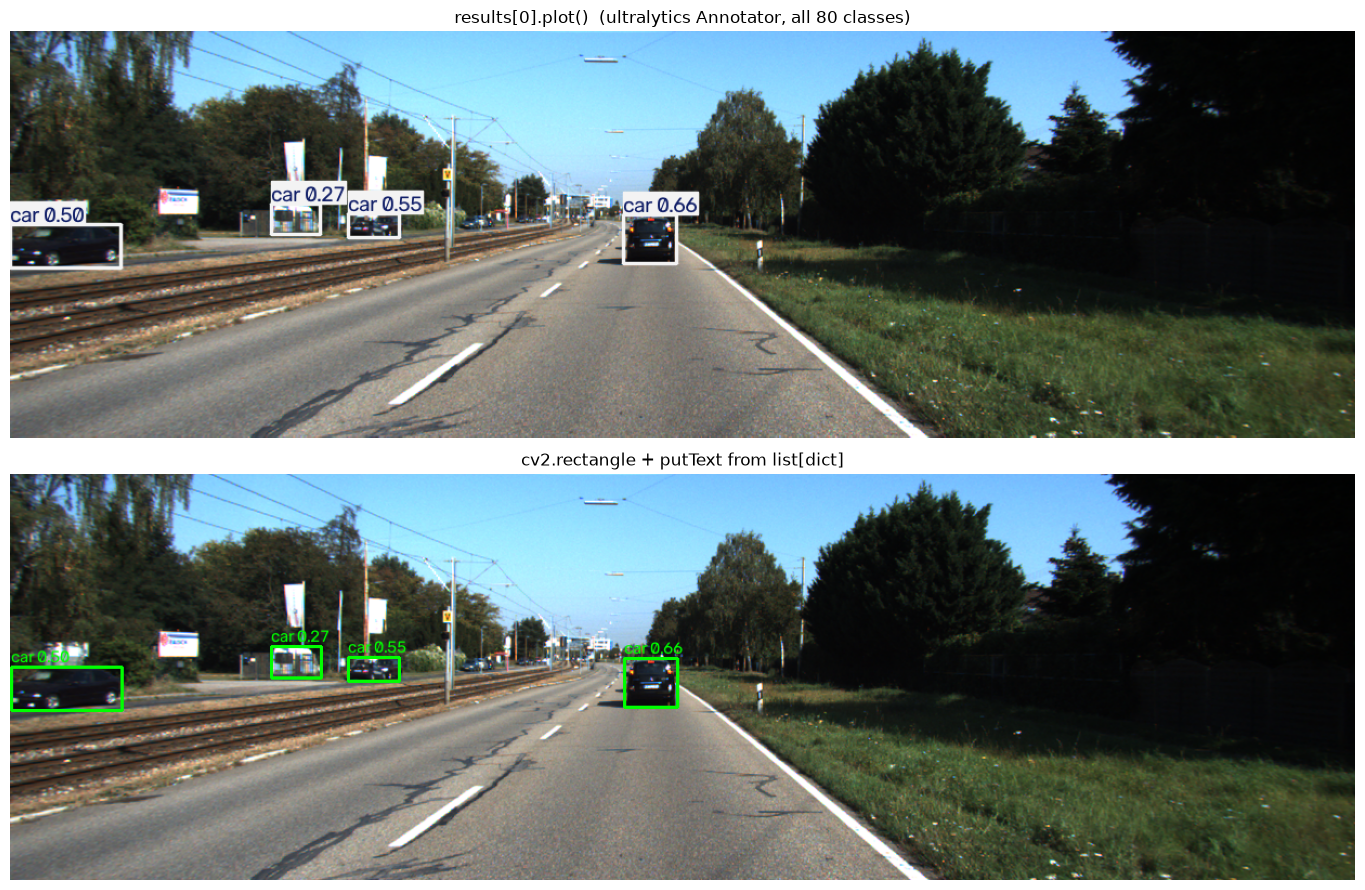

In [9]:
# B. cv2 로 직접 그리기 (dict 리스트 입력). 정수 픽셀로 반올림, 텍스트는 박스 위.
def draw_dets_cv2(image_bgr, dets, color=(0, 255, 0)):
    out = image_bgr.copy()
    for d in dets:
        x1, y1, x2, y2 = (int(round(v)) for v in d["xyxy"])
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        cv2.putText(out, f"{d['class_name']} {d['confidence']:.2f}", (x1, max(y1 - 4, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return out

vis_ours = draw_dets_cv2(img, dets)
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
axes[0].imshow(im_bgr[..., ::-1]); axes[0].set_title("results[0].plot()  (ultralytics Annotator, all 80 classes)"); axes[0].axis("off")
axes[1].imshow(vis_ours[..., ::-1]); axes[1].set_title("cv2.rectangle + putText from list[dict]"); axes[1].axis("off")
plt.tight_layout(); plt.show()

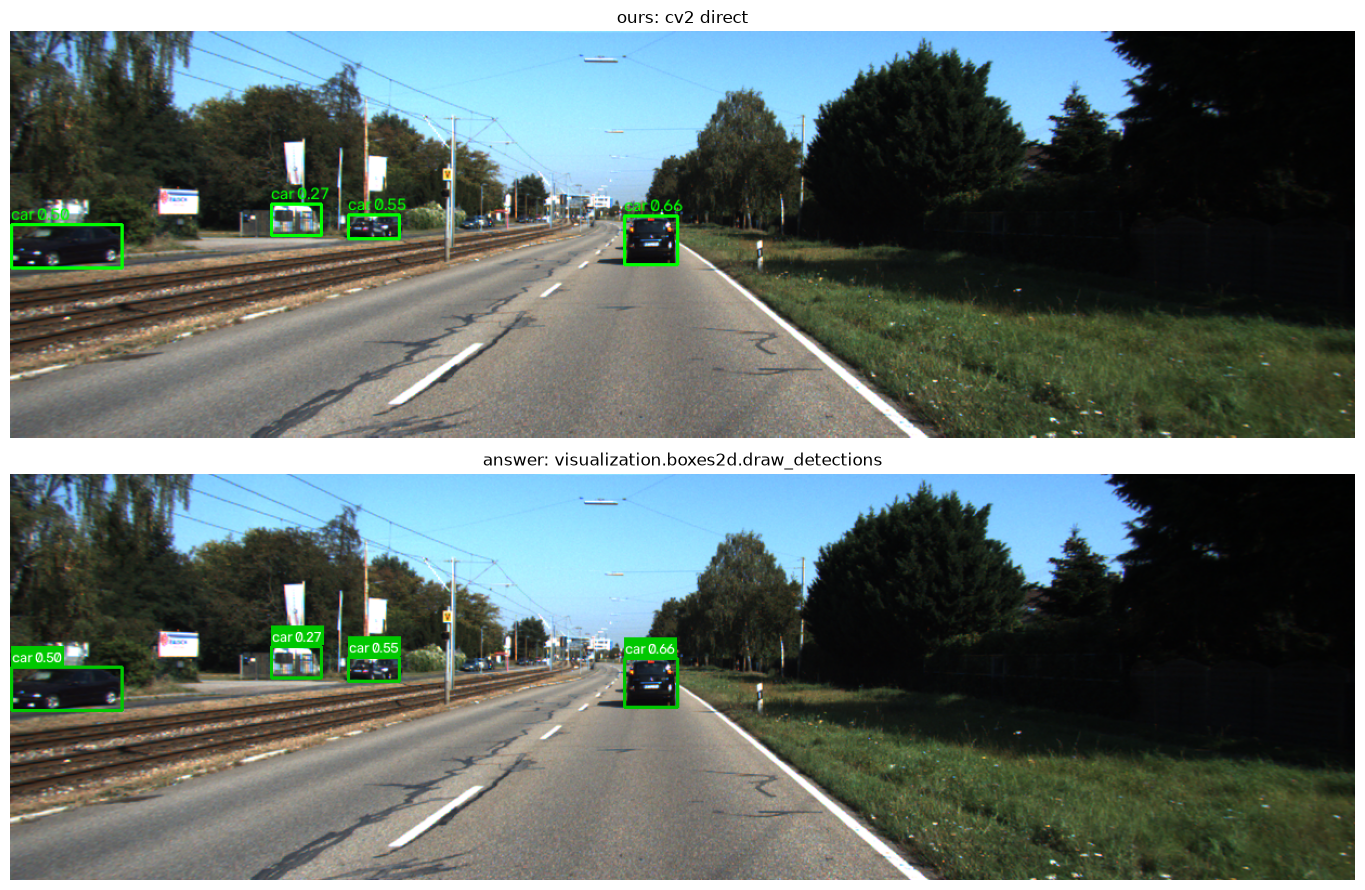

같은 박스, 다른 스타일. 정답지는 클래스별 색 + 라벨 배경, 이미지 위쪽 공간이 없으면 라벨을 박스 아래로 내린다.


In [10]:
# C. 검증: 정답지 draw_detections (클래스별 색, 라벨 배경) 과 나란히
from perceptrack3d.visualization.boxes2d import draw_detections
vis_ans = draw_detections(img, dets_ans)
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
axes[0].imshow(vis_ours[..., ::-1]); axes[0].set_title("ours: cv2 direct"); axes[0].axis("off")
axes[1].imshow(vis_ans[..., ::-1]); axes[1].set_title("answer: visualization.boxes2d.draw_detections"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print("같은 박스, 다른 스타일. 정답지는 클래스별 색 + 라벨 배경, 이미지 위쪽 공간이 없으면 라벨을 박스 아래로 내린다.")

### 조각 4. 클래스 이름·필터와 COCO ↔ KITTI 라벨 — `model.names`, `classes=`, KITTI object readme

- **검색어**: `yolov8 coco class names list model.names`, `ultralytics predict classes filter`, `kitti object detection label types`
- **출처**: ultralytics `Results.names` (predict.md 속성 표), `ultralytics/cfg/default.yaml` 의 `classes:` 줄 — https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/default.yaml — AGPL-3.0 — 2026-09-08 — `notebooks_2nd/sources/ultralytics/default.yaml` (설치본 8.4.142 에서 복사); KITTI object development kit `readme.txt` — https://www.cvlibs.net/datasets/kitti/eval_object.php ("development kit" → devkit_object.zip) — KITTI — 2026-09-08 — `notebooks_2nd/sources/kitti_devkit_object/readme.txt`
- **왜 이걸 가져오나**: 모델은 COCO 이름(80개)을 내고 정답(`tracklet_labels.xml`)은 KITTI 이름을 쓴다. 남길 클래스를 정하고, 평가 때 어떤 이름끼리 묶을지 표로 못 박아야 한다.
- **읽을 때 볼 곳**: `default.yaml` 의 `classes:` 한 줄 (id 리스트로 필터). KITTI readme 의 라벨 형식 표 `type` 행 (클래스 9개), 평가 절의 "do not count 'Van' as false positives for 'Car'".

**원문 — default.yaml (Predict settings 일부)**
```yaml
conf: # (float, optional) confidence threshold; defaults: predict=0.25, val=0.001
iou: 0.7 # (float) IoU threshold used for NMS
max_det: 300 # (int) maximum number of detections per image
agnostic_nms: False # (bool) class-agnostic NMS
classes: # (int | list[int], optional) filter by class id(s), e.g. 0 or [0,2,3]
```

**원문 — KITTI object devkit readme.txt (라벨 형식 `type`)**
```text
#Values    Name      Description
----------------------------------------------------------------------------
   1    type         Describes the type of object: 'Car', 'Van', 'Truck',
                     'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram',
                     'Misc' or 'DontCare'
```
```text
number of objects per image. In our evaluation we only evaluate detections/
objects larger than 25 pixel (height) in the image and do not count 'Van' as
false positives for 'Car' or 'Sitting Person' as false positive for 'Pedestrian'
```

In [11]:
# ORIGINAL: ultralytics docs predict.md :: Results 속성 표 — `names` : "A dictionary mapping class indices to class names."
print("COCO 80 클래스 (model.names):")
print(model.names)

COCO 80 클래스 (model.names):
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67

In [12]:
# B. 도로 객체 6개만 남기기: 이름 → id 로 바꿔 classes= 에 넘긴다 (default.yaml: "filter by class id(s), e.g. 0 or [0,2,3]")
KEEP = list(DET["keep_classes"])
keep_ids = sorted(i for i, n in model.names.items() if n in KEEP)
print("keep_classes:", KEEP, "→ ids:", keep_ids, "→", [model.names[i] for i in keep_ids])

# 프레임 186 은 신호등이 검출되는 프레임: 필터 전/후 비교
img186 = cv2.imread(str(IMAGE_DIR / f"{186:010d}.png"))
r_all = model.predict(img186, imgsz=DET["imgsz"], conf=DET["conf_threshold"], iou=DET["iou_threshold"], device=DET["device"], save=False, verbose=False)[0]
r_keep = model.predict(img186, imgsz=DET["imgsz"], conf=DET["conf_threshold"], iou=DET["iou_threshold"], device=DET["device"], save=False, verbose=False, classes=keep_ids)[0]
names_of = lambda res: [res.names[int(c)] for c in res.boxes.cls]
print("frame 186 필터 전:", len(r_all.boxes), sorted(set(names_of(r_all))))
print("frame 186 필터 후:", len(r_keep.boxes), sorted(set(names_of(r_keep))))

keep_classes: ['car', 'truck', 'bus', 'person', 'bicycle', 'motorcycle'] → ids: [0, 1, 2, 3, 5, 7] → ['person', 'bicycle', 'car', 'motorcycle', 'bus', 'truck']
frame 186 필터 전: 12 ['car', 'traffic light']
frame 186 필터 후: 10 ['car']


**COCO(모델 출력) ↔ KITTI(`tracklet_labels.xml` objectType) 매핑** — 1:1 이 아니다. `docs/decisions.md` 팀 B 절과 같은 규칙.

| COCO (검출 출력) | KITTI `objectType` | 비고 |
|---|---|---|
| car | Car, Van | Van 은 대부분 car 로 검출됨. KITTI 평가 규칙도 Van 을 Car 의 오검출로 세지 않는다 (readme 발췌) |
| truck | Truck, Van(일부) | 배송 밴이 truck 으로 나오기도 함 (프레임 163, 168) |
| bus | Truck/Van 의 오검 | 이 시퀀스에 Bus GT 없음 |
| person | Pedestrian, Person_sitting | 자전거 탄 사람이 person 으로만 나올 수도 있음 |
| bicycle + person | Cyclist | KITTI 는 한 객체, COCO 는 둘. 겹치면 Cyclist 로 합치는 규칙이 필요 |
| motorcycle | (없음) | 이 시퀀스에 없음 |
| (없음) | Tram, Misc, DontCare | 평가 제외 |

In [13]:
# C. 검증: (1) keep_ids 가 정답지 YoloDetector.class_ids 와 같은가 (2) classes= 필터 = 필터 없이 돌린 뒤 이름으로 거른 것과 같은 박스인가
print("정답지 class_ids:", det_obj.class_ids, "| 우리 keep_ids:", keep_ids, "| 동일:", det_obj.class_ids == keep_ids)
post = [i for i, n in enumerate(names_of(r_all)) if n in KEEP]                 # 필터 없이 돌린 결과에서 이름으로 사후 필터
same_boxes = np.allclose(r_all.boxes.xyxy.cpu().numpy()[post], r_keep.boxes.xyxy.cpu().numpy(), atol=1e-3)
print("classes= 필터 vs 사후 필터: 박스 수", len(post), "vs", len(r_keep.boxes), "| xyxy allclose:", same_boxes)
print("→ NMS 가 클래스별로 독립이라 다른 클래스를 먼저 버려도 남는 박스는 같다 (조각 6 의 agnostic_nms 를 켜면 달라진다).")

정답지 class_ids: [0, 1, 2, 3, 5, 7] | 우리 keep_ids: [0, 1, 2, 3, 5, 7] | 동일: True
classes= 필터 vs 사후 필터: 박스 수 10 vs 10 | xyxy allclose: True
→ NMS 가 클래스별로 독립이라 다른 클래스를 먼저 버려도 남는 박스는 같다 (조각 6 의 agnostic_nms 를 켜면 달라진다).


### 조각 5. 추론 시간 재기 — `time.perf_counter` 와 `results[0].speed`

- **검색어**: `python measure elapsed time perf_counter`, `ultralytics results speed preprocess inference postprocess`
- **출처**: Python 문서 `time.perf_counter()` — https://docs.python.org/3/library/time.html#time.perf_counter — PSF — 2026-09-08; ultralytics `Results.speed` (predict.md 속성 표: "A dictionary of preprocess, inference, and postprocess speeds in milliseconds per image.")
- **왜 이걸 가져오나**: 성능 수치는 측정 구간을 적어야 의미가 있다. 벽시계(perf_counter)로 `predict()` 한 번을 재고, ultralytics 가 내부에서 잰 세 구간 합과 비교한다.
- **읽을 때 볼 곳**: perf_counter 설명의 "highest available resolution to measure a short duration", "only the difference between the results of two calls is valid".

In [14]:
# ORIGINAL: Python docs :: time.perf_counter() — https://docs.python.org/3/library/time.html#time.perf_counter
#   Return the value (in fractional seconds) of a performance counter, i.e. a clock with the highest available
#   resolution to measure a short duration. It does include time elapsed during sleep. The clock is the same for
#   all processes. The reference point of the returned value is undefined, so that only the difference between
#   the results of two calls is valid.
import time
t0 = time.perf_counter()
_ = model.predict(img, imgsz=DET["imgsz"], conf=DET["conf_threshold"], iou=DET["iou_threshold"], device=DET["device"], classes=keep_ids, save=False, verbose=False)
elapsed = time.perf_counter() - t0
print(f"predict() 1회: {elapsed * 1000:.2f} ms")

predict() 1회: 11.77 ms


In [15]:
# B. warm-up 2회 후 20회 측정. 측정 구간 = predict() 한 번 (letterbox 전처리 + 순전파 + NMS). 이미지 로드는 제외.
def timed_predict(image):
    t0 = time.perf_counter()
    res = model.predict(image, imgsz=DET["imgsz"], conf=DET["conf_threshold"], iou=DET["iou_threshold"], device=DET["device"], classes=keep_ids, save=False, verbose=False)[0]
    return res, (time.perf_counter() - t0) * 1000.0

for _ in range(2):                                   # warm-up: 첫 호출은 커널 초기화로 수 배 느리다
    timed_predict(img)
wall, speeds = [], []
for _ in range(20):
    res_t, ms = timed_predict(img)
    wall.append(ms); speeds.append(res_t.speed)
wall = np.array(wall)
print(f"CPU threads={torch.get_num_threads()} | torch {torch.__version__} | ultralytics {ultralytics.__version__} | imgsz={DET['imgsz']} | 프레임 {FRAME}, 1242x375")
print(f"perf_counter 20회: 평균 {wall.mean():.2f} ms, 중앙값 {np.median(wall):.2f} ms, 최소 {wall.min():.2f}, 최대 {wall.max():.2f} → 약 {1000 / np.median(wall):.0f} FPS")
sp = {k: np.median([s[k] for s in speeds]) for k in ("preprocess", "inference", "postprocess")}
print("results.speed 중앙값 (ms):", {k: round(float(v), 2) for k, v in sp.items()}, f"| 합 {sum(sp.values()):.2f} ms")
print(f"벽시계 − speed 합 = {np.median(wall) - sum(sp.values()):.2f} ms  (predict() 의 파이썬 오버헤드: 인자 처리, Results 객체 생성 등)")

CPU threads=8 | torch 2.14.0+cpu | ultralytics 8.4.142 | imgsz=640 | 프레임 36, 1242x375
perf_counter 20회: 평균 11.40 ms, 중앙값 11.38 ms, 최소 11.08, 최대 11.60 → 약 88 FPS
results.speed 중앙값 (ms): {'preprocess': 0.43, 'inference': 10.45, 'postprocess': 0.33} | 합 11.21 ms
벽시계 − speed 합 = 0.16 ms  (predict() 의 파이썬 오버헤드: 인자 처리, Results 객체 생성 등)


In [16]:
# C. 검증: 정답지 detect_timed (같은 구간: predict 1회) 20회 중앙값과 비교
ans_ms = np.array([det_obj.detect_timed(img, frame_id=FRAME)[1] for _ in range(20)])
print(f"정답지 detect_timed 20회: 중앙값 {np.median(ans_ms):.2f} ms (평균 {ans_ms.mean():.2f})  | 우리: 중앙값 {np.median(wall):.2f} ms")
print("차이는 실행 시점 노이즈 범위. 둘 다 같은 predict() 호출을 같은 인자(classes 포함)로 재기 때문이다. outputs/phase4/runtime.md 는 297 프레임 기준 중앙값 13.8 ms.")

정답지 detect_timed 20회: 중앙값 10.98 ms (평균 11.14)  | 우리: 중앙값 11.38 ms
차이는 실행 시점 노이즈 범위. 둘 다 같은 predict() 호출을 같은 인자(classes 포함)로 재기 때문이다. outputs/phase4/runtime.md 는 297 프레임 기준 중앙값 13.8 ms.


### 조각 6. 실패 사례와 `agnostic_nms=True` 실험

- **검색어**: `yolo same object two boxes different classes truck bus`, `ultralytics agnostic_nms`
- **출처**: `ultralytics/cfg/default.yaml` 의 `agnostic_nms: False # (bool) class-agnostic NMS` — 위와 같은 URL/라이선스 — 2026-09-08 — `notebooks_2nd/sources/ultralytics/default.yaml`; 실패 프레임 선정은 정답지 `outputs/phase4/failures/README.md`
- **왜 이걸 가져오나**: NMS(겹친 박스 중 최고 신뢰도만 남기는 후처리)가 기본으로 **클래스별**이라 같은 물체에 truck 과 bus 박스가 둘 다 남는다. 이 옵션 하나로 결과가 어떻게 바뀌는지 직접 본다.
- **읽을 때 볼 곳**: default.yaml 의 `iou: 0.7 # (float) IoU threshold used for NMS` 와 `agnostic_nms` 두 줄.

두 프레임
1. **프레임 186 — Cyclist 미검출**: 우측 22 m 자전거 탄 사람이 person 으로도 bicycle 로도 안 나온다. COCO 에 Cyclist 클래스가 없고, 기둥과 겹쳐 두 클래스 모두 신뢰도가 낮다. 임계값을 0.05 까지 내려도 나오는지 확인한다.
2. **프레임 168 — truck+bus 이중 검출**: 좌측 배송 밴에 `truck 0.77` 과 `bus 0.54` 가 겹친다. `agnostic_nms=True` 로 켜면 클래스와 무관하게 IoU 로 억제한다.

In [17]:
# ORIGINAL: ultralytics/cfg/default.yaml :: Predict settings, AGPL-3.0 (notebooks_2nd/sources/ultralytics/default.yaml)
#   iou: 0.7 # (float) IoU threshold used for NMS
#   agnostic_nms: False # (bool) class-agnostic NMS
#   classes: # (int | list[int], optional) filter by class id(s), e.g. 0 or [0,2,3]
def predict_dicts(image, frame_id, **kw):
    """조각 1·2·4 를 합친 짧은 호출: keep 클래스만, dict 리스트로."""
    res = model.predict(image, imgsz=DET["imgsz"], conf=kw.pop("conf", DET["conf_threshold"]), iou=DET["iou_threshold"],
                        device=DET["device"], classes=keep_ids, save=False, verbose=False, **kw)[0]
    return [{"frame_id": frame_id, "class_name": res.names[int(c)], "class_id": int(c), "confidence": float(p), "xyxy": [float(v) for v in b]}
            for b, p, c in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy(), res.boxes.cls.cpu().numpy())]

frame 186 agnostic_nms=False: car 0.76, car 0.71, car 0.70, car 0.64, car 0.61, car 0.55, car 0.53, car 0.31, car 0.27, car 0.25
frame 186 agnostic_nms=True : car 0.76, car 0.71, car 0.70, car 0.64, car 0.61, car 0.55, car 0.53, car 0.31, car 0.27, car 0.25
frame 168 agnostic_nms=False: truck 0.77, car 0.74, bus 0.54, car 0.29, car 0.25, car 0.25
frame 168 agnostic_nms=True : truck 0.77, car 0.74, car 0.29, car 0.25, car 0.25


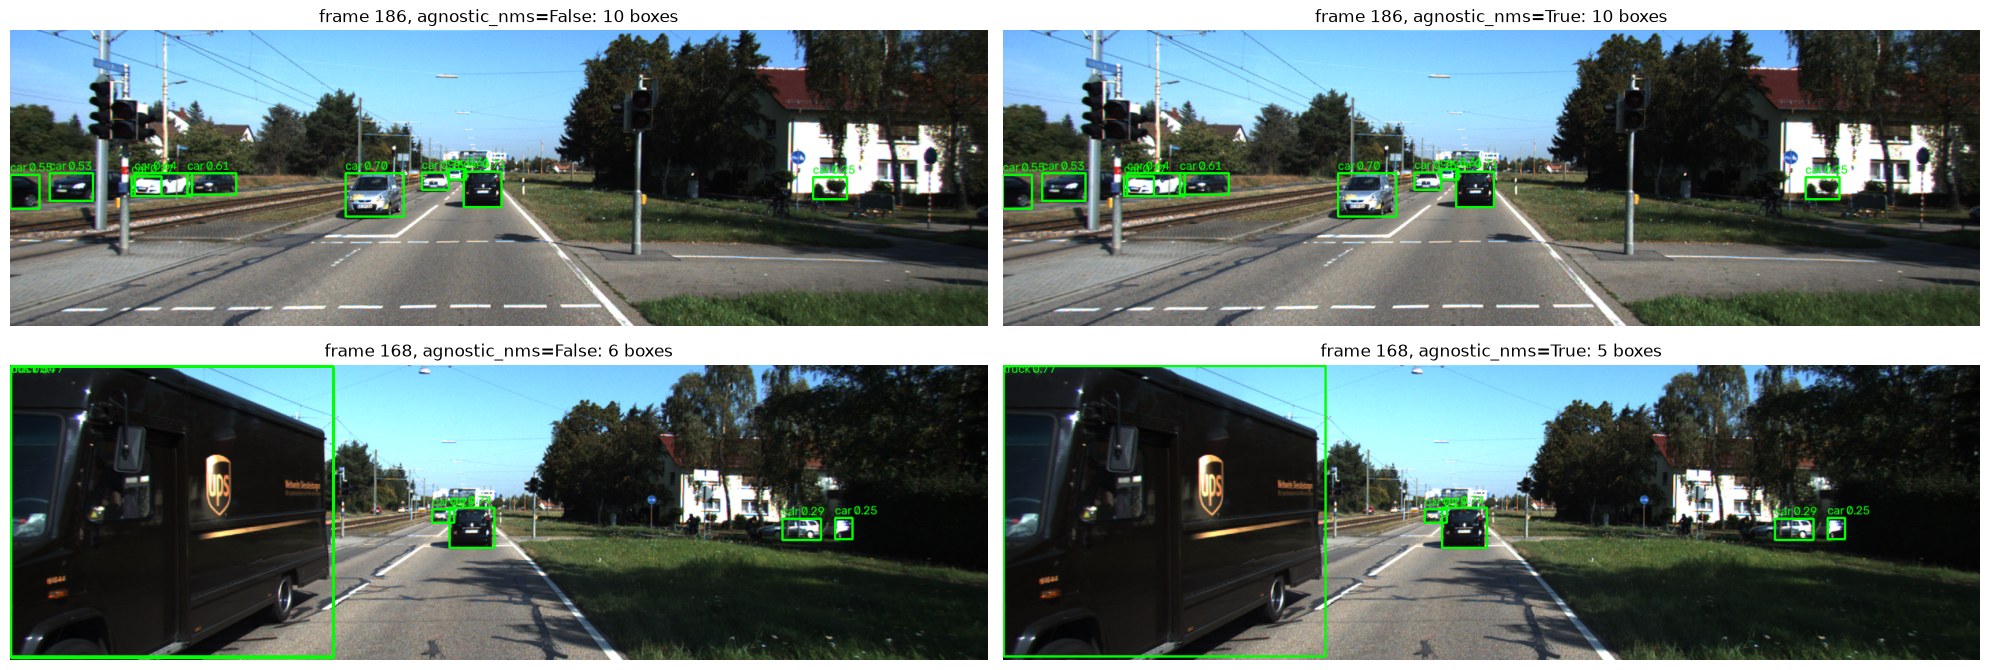


frame 186, conf=0.05 로 내려도 person/bicycle 이 나오는가: ['car'] → 검출 17 개 (Cyclist 는 임계값 문제가 아니라 클래스/실루엣 문제)


In [18]:
# B. 프레임 186, 168: 기본(클래스별 NMS) vs agnostic_nms=True
summ = lambda ds: ", ".join(f"{d['class_name']} {d['confidence']:.2f}" for d in ds)
fig, axes = plt.subplots(2, 2, figsize=(20, 7))
runs = {}
for row, fid in enumerate((186, 168)):
    im = cv2.imread(str(IMAGE_DIR / f"{fid:010d}.png"))
    for col, ag in enumerate((False, True)):
        ds = predict_dicts(im, fid, agnostic_nms=ag)
        runs[(fid, ag)] = ds
        axes[row, col].imshow(draw_dets_cv2(im, ds)[..., ::-1]); axes[row, col].axis("off")
        axes[row, col].set_title(f"frame {fid}, agnostic_nms={ag}: {len(ds)} boxes")
        print(f"frame {fid} agnostic_nms={ag!s:5}: {summ(ds)}")
plt.tight_layout(); plt.show()

low = predict_dicts(cv2.imread(str(IMAGE_DIR / f"{186:010d}.png")), 186, conf=0.05)
print("\nframe 186, conf=0.05 로 내려도 person/bicycle 이 나오는가:", sorted(set(d["class_name"] for d in low)), "→ 검출", len(low), "개 (Cyclist 는 임계값 문제가 아니라 클래스/실루엣 문제)")

In [19]:
# C. 검증: 기본 설정 결과는 정답지 detections.json 과 같고, agnostic_nms=True 는 프레임 168 에서 bus 박스가 사라진다
for fid in (186, 168):
    a = ans_all[str(fid)]; o = runs[(fid, False)]; g = runs[(fid, True)]
    same = len(a) == len(o) and all(x["class_name"] == y["class_name"] and np.allclose(x["xyxy"], y["xyxy"], atol=1e-3) for x, y in zip(a, o))
    print(f"frame {fid}: 정답지 {len(a)}개 vs 기본 {len(o)}개 → 일치 {same} | agnostic {len(g)}개 → 사라진 것: {sorted(set(summ([d]) for d in o) - set(summ([d]) for d in g))}")
print("정답지는 기본(클래스별 NMS)을 유지했다: agnostic NMS 는 붙어 있는 다른 클래스(사람 옆 자전거)까지 지울 수 있어서 (docs/decisions.md 팀 B 절). 융합 단계에서 같은 3D 위치의 중복을 따로 제거한다.")

frame 186: 정답지 10개 vs 기본 10개 → 일치 True | agnostic 10개 → 사라진 것: []
frame 168: 정답지 6개 vs 기본 6개 → 일치 True | agnostic 5개 → 사라진 것: ['bus 0.54']
정답지는 기본(클래스별 NMS)을 유지했다: agnostic NMS 는 붙어 있는 다른 클래스(사람 옆 자전거)까지 지울 수 있어서 (docs/decisions.md 팀 B 절). 융합 단계에서 같은 3D 위치의 중복을 따로 제거한다.


### 이어붙이기 — `detect(img, frame_id)` 와 JSON 저장/로드

조각 1(입력 형식) + 조각 4(클래스 필터) + 조각 2(dict 변환) 를 한 함수로. 박스는 이미지 경계 안으로 자르고, 저장 형식은 정답지와 같은 `{"36": [ {...}, ... ]}` 로 맞춘다.

In [20]:
def detect(image_bgr, frame_id):
    """(H,W,3) uint8 BGR → list[dict]. 신뢰도 내림차순 (ultralytics 기본 정렬)."""
    assert image_bgr.ndim == 3 and image_bgr.shape[2] == 3 and image_bgr.dtype == np.uint8, image_bgr.shape   # 모듈 경계 검사
    h, w = image_bgr.shape[:2]
    res = model.predict(image_bgr, imgsz=DET["imgsz"], conf=DET["conf_threshold"], iou=DET["iou_threshold"],   # 조각 1
                        device=DET["device"], classes=keep_ids, save=False, verbose=False)[0]                   # 조각 4
    out = []
    for b, p, c in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy(), res.boxes.cls.cpu().numpy()):   # 조각 2
        x1, y1, x2, y2 = np.clip(b, [0, 0, 0, 0], [w, h, w, h])                # 경계 밖 좌표 방지
        if x2 <= x1 or y2 <= y1:
            continue
        out.append({"frame_id": int(frame_id), "class_name": res.names[int(c)], "class_id": int(c),
                    "confidence": float(p), "xyxy": [float(x1), float(y1), float(x2), float(y2)]})
    return out

def save_detections(dets_by_frame, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump({str(k): dets_by_frame[k] for k in sorted(dets_by_frame)}, f, indent=1)

def load_detections(path):
    with open(path, encoding="utf-8") as f:
        return {int(k): v for k, v in json.load(f).items()}

frames = [0, 36, 64, 168, 186, 264]
dets_by_frame, ms_list = {}, []
for fid in frames:
    im = cv2.imread(str(IMAGE_DIR / f"{fid:010d}.png"))
    t0 = time.perf_counter()
    dets_by_frame[fid] = detect(im, fid)
    ms_list.append((time.perf_counter() - t0) * 1000)
json_path = OUT_DIR / "04_detections_2nd.json"
save_detections(dets_by_frame, json_path)
loaded = load_detections(json_path)
print("저장:", json_path, "| 프레임:", list(loaded), "| 프레임당 %.1f ms (중앙값, detect() 전체 = predict + dict 변환)" % np.median(ms_list))
for fid in frames:
    print(f"  frame {fid:3d}: {len(loaded[fid])}개 — {summ(loaded[fid])}")

저장: /home/ingon/study/PercepTrack3D/outputs/notebooks_2nd/04_detections_2nd.json | 프레임: [0, 36, 64, 168, 186, 264] | 프레임당 14.0 ms (중앙값, detect() 전체 = predict + dict 변환)
  frame   0: 3개 — car 0.79, car 0.49, car 0.41
  frame  36: 4개 — car 0.66, car 0.55, car 0.50, car 0.27
  frame  64: 5개 — car 0.64, car 0.54, car 0.42, car 0.39, car 0.35
  frame 168: 6개 — truck 0.77, car 0.74, bus 0.54, car 0.29, car 0.25, car 0.25
  frame 186: 10개 — car 0.76, car 0.71, car 0.70, car 0.64, car 0.61, car 0.55, car 0.53, car 0.31, car 0.27, car 0.25
  frame 264: 6개 — car 0.78, car 0.71, car 0.67, car 0.63, car 0.47, car 0.38


In [21]:
# 최종 검증: 6 프레임 모두 정답지 detections.json 과 개수·클래스·xyxy(1e-3)·conf(1e-4) 일치
print(f"{'frame':>6} {'ours':>5} {'ans':>5} {'class==':>8} {'xyxy max|Δ|':>12} {'conf max|Δ|':>12}")
for fid in frames:
    o, a = loaded[fid], ans_all[str(fid)]
    same_cls = [d["class_name"] for d in o] == [d["class_name"] for d in a]
    dxy = max(np.abs(np.array(x["xyxy"]) - np.array(y["xyxy"])).max() for x, y in zip(o, a)) if same_cls else float("nan")
    dcf = max(abs(x["confidence"] - y["confidence"]) for x, y in zip(o, a)) if same_cls else float("nan")
    print(f"{fid:6d} {len(o):5d} {len(a):5d} {str(same_cls):>8} {dxy:12.5f} {dcf:12.6f}")
    assert len(o) == len(a) and same_cls and dxy < 1e-3 and dcf < 1e-4
print("6 프레임 모두 정답지와 일치")

 frame  ours   ans  class==  xyxy max|Δ|  conf max|Δ|
     0     3     3     True      0.00000     0.000000
    36     4     4     True      0.00000     0.000000
    64     5     5     True      0.00000     0.000000
   168     6     6     True      0.00000     0.000000
   186    10    10     True      0.00000     0.000000
   264     6     6     True      0.00000     0.000000
6 프레임 모두 정답지와 일치


### 여기서 배우는 것

- **입력 색 순서는 문서로 확정한다.** ultralytics 는 ndarray 를 "HWC, BGR, uint8" 로 받으므로 `cv2.imread` 결과를 그대로 넣는다. RGB 로 바꿔 넣으면 오류 없이 돌아가면서 신뢰도만 조용히 떨어진다 — 가장 찾기 어려운 실수.
- **결과는 torch 텐서다.** `.cpu().numpy()` 를 거쳐야 numpy/JSON 이 된다. `xyxy` 는 letterbox(640×192)에서 **원본 픽셀로 되돌린 값**이라 그대로 Phase 3 의 `uv` 와 비교할 수 있다.
- **`classes=` 필터와 사후 필터는 같은 박스를 준다.** NMS 가 클래스별로 독립이기 때문이다. 같은 이유로 truck+bus 이중 박스가 남고, `agnostic_nms=True` 는 그것을 없애지만 사람 옆 자전거도 지울 수 있다. 옵션 하나가 실패 사례를 바꾸는 지점.
- **COCO ↔ KITTI 는 1:1 이 아니다.** car ↔ {Car, Van}, person+bicycle ↔ Cyclist. 평가 전에 매핑 규칙을 표로 적어 두지 않으면 Phase 8 에서 "미검출" 이 라벨 차이인지 모델 한계인지 구분할 수 없다.
- **시간은 구간을 적어야 수치가 된다.** 벽시계(`perf_counter`, predict 1회)와 ultralytics `speed`(전처리/추론/후처리)는 몇 ms 차이가 나며, 그 차이가 파이썬 오버헤드다. warm-up 없이 첫 호출을 재면 수 배 큰 값이 나온다.

### 자가 점검 3문제

1. `cv2.imread` 로 읽은 이미지를 `cv2.cvtColor(..., COLOR_BGR2RGB)` 로 바꿔 `model.predict` 에 넣으면 어떤 일이 생기는가? 문서의 어느 줄이 근거인가?
2. 프레임 168 에서 `agnostic_nms=True` 를 켜면 어떤 박스가 왜 사라지는가? 정답지가 그래도 기본값을 유지한 이유는?
3. `results[0].boxes.xyxy` 의 값은 어느 해상도의 픽셀인가 (640 letterbox 인가, 원본 1242×375 인가)? 그것을 Phase 3 의 `uv` 와 바로 비교해도 되는 이유는?

<details>
<summary>답</summary>

1. 오류 없이 돌아가지만 모델은 RGB 를 BGR 로 해석해 색이 뒤바뀐 이미지를 보게 되고, 신뢰도가 떨어지거나 박스가 바뀐다. 근거는 "Inference Sources" 표의 OpenCV/NumPy 행: `HWC format with BGR channels uint8 (0-255)`.
2. `truck 0.77` 과 `bus 0.54` 가 같은 밴에 겹쳐 있는데, 기본 NMS 는 클래스별이라 서로 억제하지 않는다. agnostic 을 켜면 클래스와 무관하게 IoU 로 억제해 신뢰도가 낮은 `bus 0.54` 가 사라진다. 정답지는 붙어 있는 다른 클래스(사람 옆 자전거)까지 지워질 위험 때문에 기본값을 유지하고, 융합 단계에서 같은 3D 위치의 중복을 제거한다.
3. 원본 1242×375 픽셀이다. ultralytics 가 letterbox 로 640×192 에 넣어 추론한 뒤 박스를 원본 좌표로 되돌려 준다(`orig_shape` 기준). 그래서 Phase 3 의 `uv`(같은 image_02 픽셀 프레임)와 바로 비교할 수 있다.

</details>